### Import Dataset Menggunakan Kaggle API

In [1]:
import os
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    f.write('{"username":"nauvalsainsdataunesa","key":"3909a8d8d095fb4a9a2ca24c734870d1"}')
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

!pip install -q kaggle
!kaggle datasets download -d pythonafroz/solar-panel-images --unzip -p solar-panel-images

print("Contents of solar-panel-images:", os.listdir("solar-panel-images"))

Dataset URL: https://www.kaggle.com/datasets/pythonafroz/solar-panel-images
License(s): unknown
100% 305M/305M [00:18<00:00, 16.9MB/s]

Contents of solar-panel-images: ['Faulty_solar_panel']


### Eksplorasi Dataset / EDA Distribusi Kelas

/tmp/ipykernel_29566/3796134089.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(stats.keys()), y=list(stats.values()), palette='viridis')


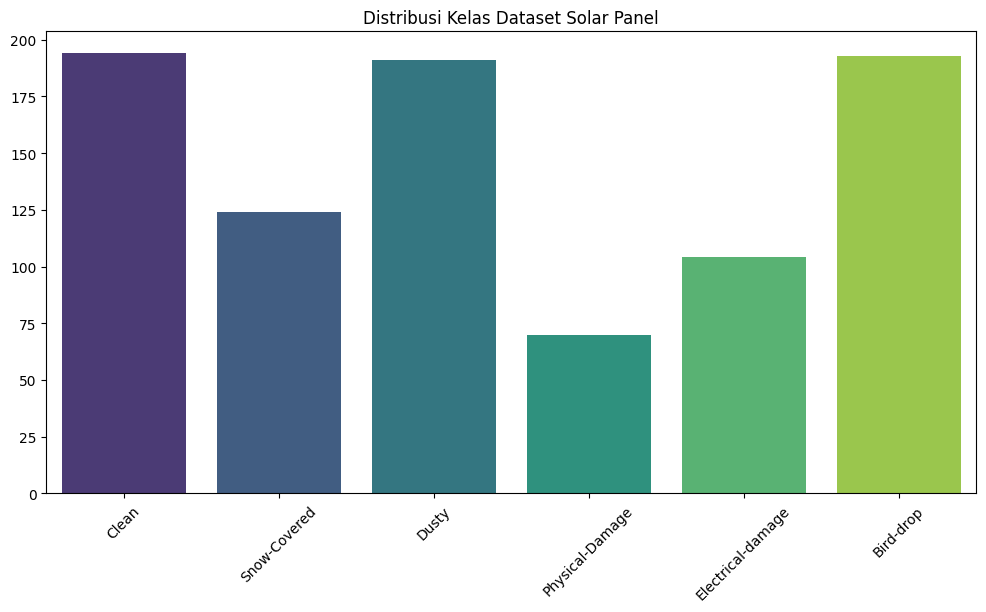

Jumlah Data: {'Clean': 194, 'Snow-Covered': 124, 'Dusty': 191, 'Physical-Damage': 70, 'Electrical-damage': 104, 'Bird-drop': 193}


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Updated path based on common Kaggle dataset structures
dataset_path = 'solar-panel-images/Faulty_solar_panel/Faulty_solar_panel'
if not os.path.exists(dataset_path):
    dataset_path = 'solar-panel-images/Faulty_solar_panel'

categories = [c for c in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, c))]
stats = {cat: len(os.listdir(os.path.join(dataset_path, cat))) for cat in categories}

plt.figure(figsize=(12, 6))
sns.barplot(x=list(stats.keys()), y=list(stats.values()), palette='viridis')
plt.title('Distribusi Kelas Dataset Solar Panel')
plt.xticks(rotation=45)
plt.show()

print("Jumlah Data:", stats)

### Pembagian Dataset menjadi Train, Validation, dan Test

In [3]:
!pip install -q split-folders
import splitfolders
import os

input_folder = 'solar-panel-images/Faulty_solar_panel/Faulty_solar_panel'
if not os.path.exists(input_folder):
    input_folder = 'solar-panel-images/Faulty_solar_panel'

output_folder = 'dataset_split'

# Split 80% Train, 10% Val, 10% Test
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .1, .1), group_prefix=None, move=False)

Copying files: 875 files [00:00, 918.56 files/s] 


### Preprocessing dan Augmentasi Data Gambar

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'dataset_split/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    'dataset_split/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    'dataset_split/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 693 images belonging to 6 classes.
Found 85 images belonging to 6 classes.
Found 91 images belonging to 6 classes.


## MOBILENETV2

### Model Transfer Learning MobileNetV2

In [5]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.4141 - loss: 1.5990 - val_accuracy: 0.5529 - val_loss: 1.1759
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 883ms/step - accuracy: 0.5628 - loss: 1.1401 - val_accuracy: 0.6235 - val_loss: 1.0125
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 950ms/step - accuracy: 0.6349 - loss: 0.9879 - val_accuracy: 0.6353 - val_loss: 0.9685
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 940ms/step - accuracy: 0.6710 - loss: 0.8792 - val_accuracy: 0.6941 - val_loss: 0.8860
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 887ms/step - accuracy: 0.6912 - loss: 0.8530 - val_accuracy: 0.7294 - val_loss: 0.8142
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 913ms/step - accuracy: 0.7027 - loss: 0.7876 - val_accuracy: 0.7176 - val_loss: 0.7959
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 855ms/step - accuracy: 0.7157 - loss: 0.7650 - val_accuracy: 0.7294 - val_loss: 0.8013
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 905ms/step - accuracy: 0.7273 - loss: 0.7112 - val_accurac

### Evaluasi Model MobileNetV2

In [7]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Prediksi pada test set
test_generator.reset()
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Metrik
acc = accuracy_score(y_true, y_pred)
f1_weighted = f1_score(y_true, y_pred, average="weighted")
f1_macro = f1_score(y_true, y_pred, average="macro")

print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))
print("="*60)
print(f"Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"F1 Score (weighted): {f1_weighted:.4f}")
print(f"F1 Score (macro)   : {f1_macro:.4f}")
print("="*60)

3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 7s/step
CLASSIFICATION REPORT
                   precision    recall  f1-score   support

        Bird-drop       0.61      0.55      0.58        20
            Clean       0.63      0.85      0.72        20
            Dusty       0.68      0.85      0.76        20
Electrical-damage       0.89      0.73      0.80        11
  Physical-Damage       1.00      0.14      0.25         7
     Snow-Covered       1.00      0.85      0.92        13

         accuracy                           0.71        91
        macro avg       0.80      0.66      0.67        91
     weighted avg       0.75      0.71      0.70        91

Test Accuracy : 0.7143 (71.43%)
F1 Score (weighted): 0.6992
F1 Score (macro)   : 0.6708


### Evaluasi Proses Training Model MobileNetV2

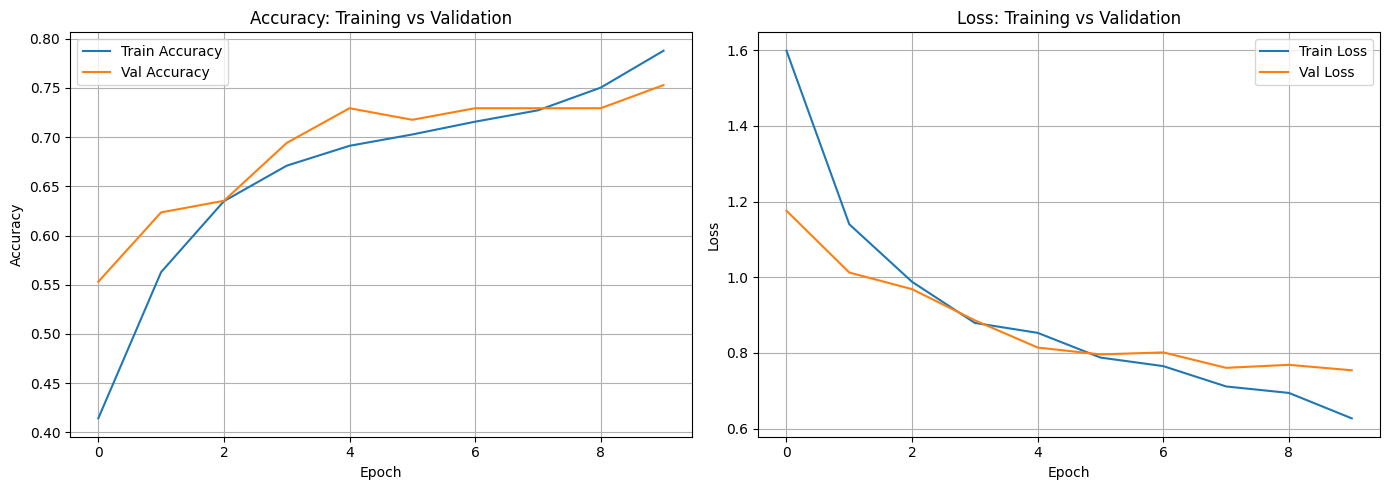

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy: Training vs Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss: Training vs Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Fine-Tuning Model MobileNetV2

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

base = None
for layer in model.layers:
    if hasattr(layer, "layers") and len(layer.layers) > 10:
        base = layer
        break

if base:
    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False
    print(f"Fine-tuning {sum(1 for l in base.layers if l.trainable)} layers")
else:
    # Fallback: unfreeze all
    for layer in model.layers:
        layer.trainable = True

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7)
]

print("Memulai fine-tuning...")

history_ft = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks
)

Memulai fine-tuning...
Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.4603 - loss: 1.4691 - val_accuracy: 0.7294 - val_loss: 0.7839 - learning_rate: 1.0000e-05
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 872ms/step - accuracy: 0.5180 - loss: 1.3527 - val_accuracy: 0.6941 - val_loss: 0.8248 - learning_rate: 1.0000e-05
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 888ms/step - accuracy: 0.5556 - loss: 1.2546 - val_accuracy: 0.6706 - val_loss: 0.8659 - learning_rate: 1.0000e-05
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 938ms/step - accuracy: 0.6075 - loss: 1.1001 - val_accuracy: 0.6824 - val_loss: 0.9173 - learning_rate: 1.0000e-05
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 881ms/step - accuracy: 0.5931 - loss: 1.1048 - val_accuracy: 0.6706 - val_loss: 0.9305 - learning_rate: 5.0000e-06
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 925ms/step - accuracy: 0.6133 - loss: 1.0528 - val_accuracy: 0.6588 - val_loss: 0.9443 - learning_rate: 5.0000e-06


Evaluasi Model Sebelum dan Setelah Fine-Tuning

In [10]:
test_generator.reset()

y_pred_probs_ft = model.predict(test_generator)
y_pred_ft = np.argmax(y_pred_probs_ft, axis=1)

acc_ft = accuracy_score(y_true, y_pred_ft)
f1_ft = f1_score(y_true, y_pred_ft, average="weighted")

print(classification_report(y_true, y_pred_ft, target_names=class_names))

print("Akurasi sebelum fine-tuning:", round(acc, 4))
print("Akurasi setelah fine-tuning:", round(acc_ft, 4))

print("F1 sebelum fine-tuning:", round(f1_weighted, 4))
print("F1 setelah fine-tuning:", round(f1_ft, 4))

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step
                   precision    recall  f1-score   support

        Bird-drop       0.63      0.60      0.62        20
            Clean       0.64      0.90      0.75        20
            Dusty       0.71      0.85      0.77        20
Electrical-damage       0.89      0.73      0.80        11
  Physical-Damage       1.00      0.14      0.25         7
     Snow-Covered       1.00      0.77      0.87        13

         accuracy                           0.73        91
        macro avg       0.81      0.66      0.68        91
     weighted avg       0.76      0.73      0.71        91

Akurasi sebelum fine-tuning: 0.7143
Akurasi setelah fine-tuning: 0.7253
F1 sebelum fine-tuning: 0.6992
F1 setelah fine-tuning: 0.7101


Visualisasi Performa Fine-Tuning

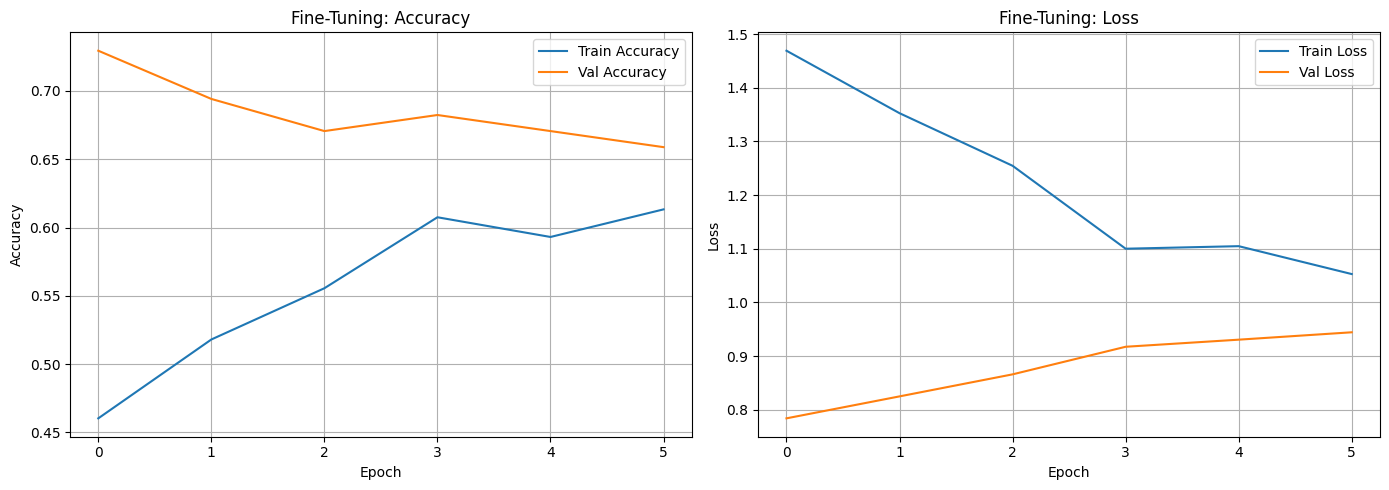

In [11]:
# Plot fine-tuning history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_ft.history["accuracy"], label="Train Accuracy")
axes[0].plot(history_ft.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Fine-Tuning: Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_ft.history["loss"], label="Train Loss")
axes[1].plot(history_ft.history["val_loss"], label="Val Loss")
axes[1].set_title("Fine-Tuning: Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## VGG16

### Feature Extraction Menggunakan VGG16

In [12]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Flatten
from tensorflow.keras.models import Model

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

x = Flatten()(base_model.output)

feature_extractor = Model(
    inputs=base_model.input,
    outputs=x
)

base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Ekstraksi fitur dataset menggunakan VGG16

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input


dataset_path = "solar-panel-images/Faulty_solar_panel"


datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

data_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

features = feature_extractor.predict(data_generator)
print("Shape fitur:", features.shape)

Found 885 images belonging to 6 classes.


28/28 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step
Shape fitur: (885, 25088)


Penyimpanan Fitur Hasil Ekstraksi CNN

In [14]:
import numpy as np

np.save("fitur_cnn.npy", features)

print("Feature vector berhasil disimpan!")

Feature vector berhasil disimpan!


### Training Model Random Forest

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Menyiapkan fitur dan label
X = features
y = data_generator.classes

# Membagi data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Membuat dan melatih model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Training Random Forest selesai!")

Training Random Forest selesai!


### Evaluasi Model Random Forest

In [16]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Prediksi data uji
y_pred_rf = rf_model.predict(X_test)

# Evaluasi model
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

print("Classification Report")
print(classification_report(y_test, y_pred_rf))

print(f"Accuracy : {acc_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")

Classification Report
              precision    recall  f1-score   support

           0       0.64      0.73      0.68        41
           1       0.66      0.71      0.68        38
           2       0.67      0.82      0.74        38
           3       0.88      0.67      0.76        21
           4       1.00      0.36      0.53        14
           5       1.00      0.88      0.94        25

    accuracy                           0.73       177
   macro avg       0.81      0.69      0.72       177
weighted avg       0.76      0.73      0.73       177

Accuracy : 0.7288
F1 Score : 0.7268


Confusion Matrix Random Forest


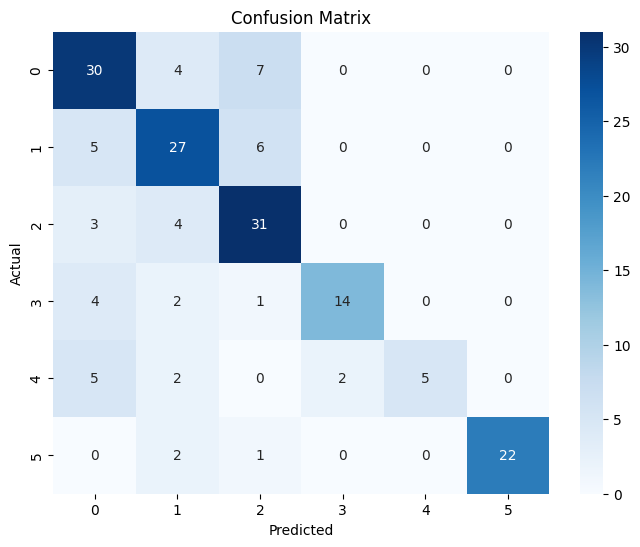

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Support Vector Machine (SVM) Classifier

In [18]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
)

svm_model.fit(X_train, y_train)

print("Training SVM selesai!")

Training SVM selesai!


### Evaluasi Model SVM

In [19]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

y_pred_svm = svm_model.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm, average="weighted")

print("Classification Report")
print(classification_report(y_test, y_pred_svm))

print(f"Accuracy : {acc_svm:.4f}")
print(f"F1 Score : {f1_svm:.4f}")

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.61      0.70        41
           1       0.74      0.61      0.67        38
           2       0.58      0.82      0.68        38
           3       0.77      0.48      0.59        21
           4       1.00      0.21      0.35        14
           5       0.49      0.92      0.64        25

    accuracy                           0.65       177
   macro avg       0.74      0.61      0.61       177
weighted avg       0.72      0.65      0.64       177

Accuracy : 0.6497
F1 Score : 0.6405


### Gradient Boosting Classifier

In [20]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Training Gradient Boosting selesai!")

Training Gradient Boosting selesai!


### Evaluasi Model Gradient Boosting

In [21]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

y_pred_gb = gb_model.predict(X_test)

acc_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb, average="weighted")

print("Classification Report")
print(classification_report(y_test, y_pred_gb))

print(f"Accuracy : {acc_gb:.4f}")
print(f"F1 Score : {f1_gb:.4f}")

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.66      0.69        41
           1       0.71      0.84      0.77        38
           2       0.69      0.82      0.75        38
           3       0.75      0.57      0.65        21
           4       0.42      0.36      0.38        14
           5       0.95      0.84      0.89        25

    accuracy                           0.72       177
   macro avg       0.71      0.68      0.69       177
weighted avg       0.73      0.72      0.72       177

Accuracy : 0.7232
F1 Score : 0.7199


### Perbandingan Performa Model

In [22]:
import pandas as pd

hasil_model = pd.DataFrame({
    "Model": [
        "MobileNetV2",
        "MobileNetV2 (Fine-Tuning)",
        "Random Forest",
        "SVM",
        "Gradient Boosting"
    ],
    "Accuracy": [
        round(acc, 4),
        round(acc_ft, 4),
        round(acc_rf, 4),
        round(acc_svm, 4),
        round(acc_gb, 4)
    ],
    "F1 Score": [
        round(f1_weighted, 4),
        round(f1_ft, 4),
        round(f1_rf, 4),
        round(f1_svm, 4),
        round(f1_gb, 4)
    ]
})

hasil_model

,Model,Accuracy,F1 Score
0,MobileNetV2,0.7143,0.6992
1,MobileNetV2 (Fine-Tuning),0.7253,0.7101
2,Random Forest,0.7288,0.7268
3,SVM,0.6497,0.6405
4,Gradient Boosting,0.7232,0.7199


### STACKING & EVALUASI

In [23]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Define base learners
estimators = [
    ('rf', rf_model),
    ('svm', svm_model),
    ('gb', gb_model)
]

# Stacking dengan Logistic Regression sebagai meta-model
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

stacking_model.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(n_jobs=-1,
                                                       random_state=42)),
                               ('svm',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('svc',
                                                 SVC(C=10, random_state=42))])),
                               ('gb',
                                GradientBoostingClassifier(random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000))

EVALUASI STACKING

In [24]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

y_pred_stack = stacking_model.predict(X_test)

acc_stack = accuracy_score(y_test, y_pred_stack)
f1_stack = f1_score(y_test, y_pred_stack, average="weighted")

print("="*60)
print("CLASSIFICATION REPORT - STACKING")
print("="*60)
print(classification_report(y_test, y_pred_stack))
print(f"Accuracy : {acc_stack:.4f} ({acc_stack*100:.2f}%)")
print(f"F1 Score : {f1_stack:.4f}")

CLASSIFICATION REPORT - STACKING
              precision    recall  f1-score   support

           0       0.74      0.63      0.68        41
           1       0.71      0.79      0.75        38
           2       0.69      0.87      0.77        38
           3       0.71      0.71      0.71        21
           4       1.00      0.43      0.60        14
           5       0.92      0.92      0.92        25

    accuracy                           0.75       177
   macro avg       0.80      0.73      0.74       177
weighted avg       0.77      0.75      0.75       177

Accuracy : 0.7514 (75.14%)
F1 Score : 0.7464


CONFUSION MATRIX (3 MODEL + STACKING)

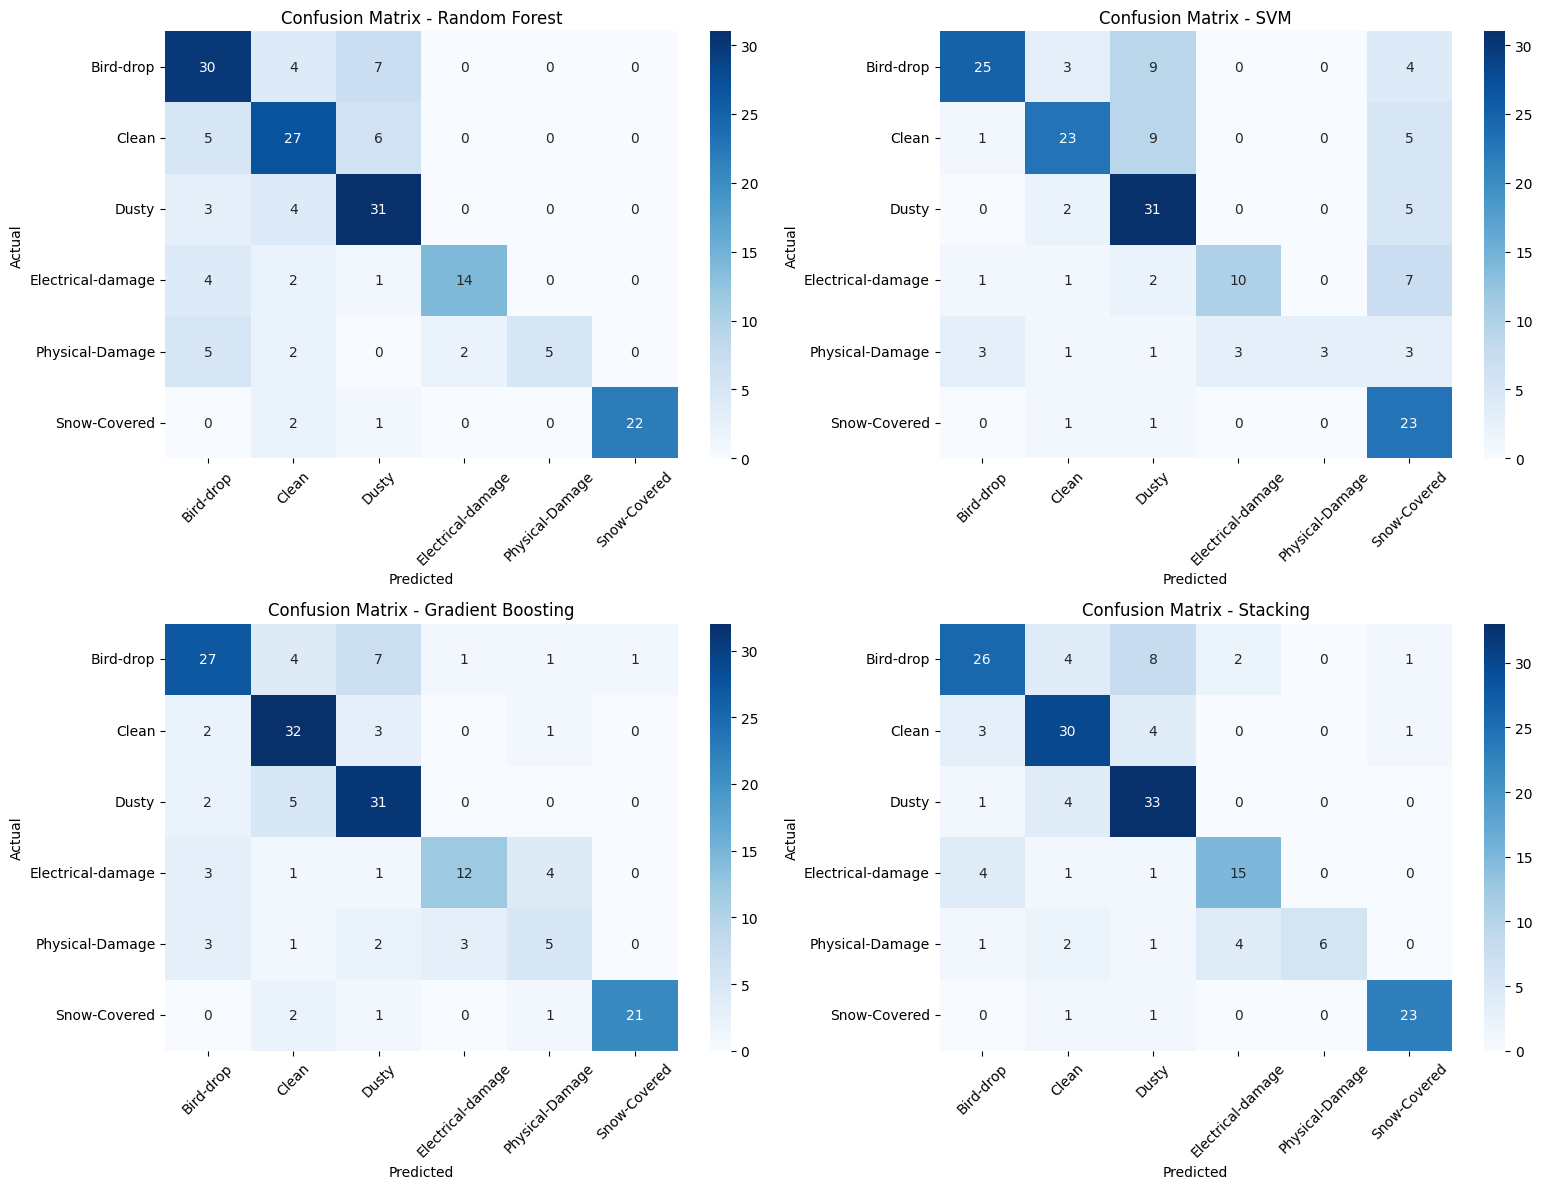

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = list(data_generator.class_indices.keys())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_preds = [
    ("Random Forest", y_pred_rf),
    ("SVM", y_pred_svm),
    ("Gradient Boosting", y_pred_gb),
    ("Stacking", y_pred_stack)
]

for ax, (name, y_pred) in zip(axes.flatten(), models_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names, ax=ax)
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### PERBANDINGAN SEMUA MODEL

                    Model  Accuracy  F1 Score
              MobileNetV2    0.7473    0.7472
MobileNetV2 (Fine-Tuning)    0.7582    0.7569
            Random Forest    0.7288    0.7268
                      SVM    0.6497    0.6405
        Gradient Boosting    0.7232    0.7199
                 Stacking    0.7514    0.7464


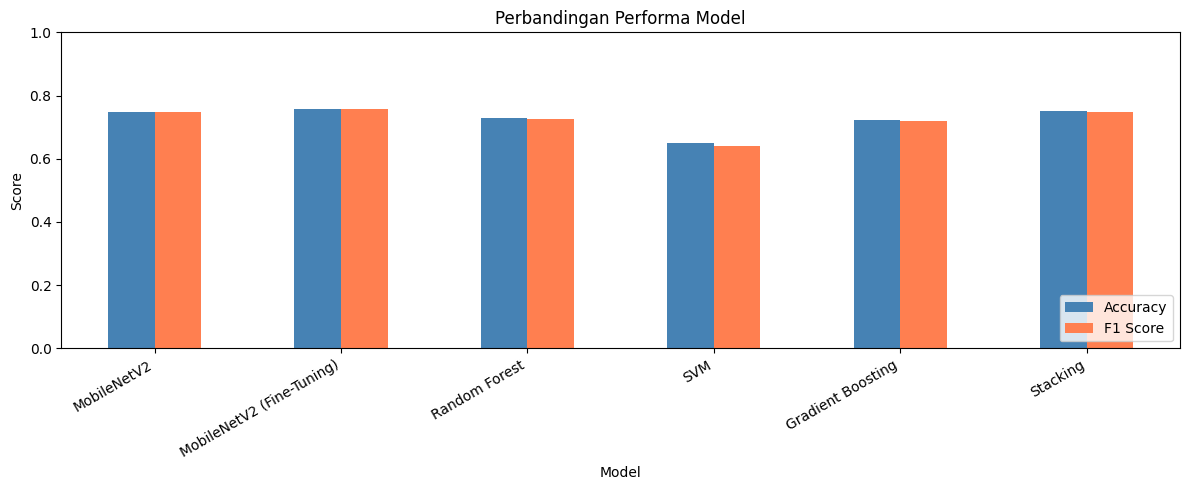

In [26]:
hasil_model = pd.DataFrame({
    "Model": ["MobileNetV2", "MobileNetV2 (Fine-Tuning)",
              "Random Forest", "SVM", "Gradient Boosting", "Stacking"],
    "Accuracy": [0.7473, 0.7582, round(acc_rf, 4),
                 round(acc_svm, 4), round(acc_gb, 4), round(acc_stack, 4)],
    "F1 Score": [0.7472, 0.7569, round(f1_rf, 4),
                 round(f1_svm, 4), round(f1_gb, 4), round(f1_stack, 4)]
})

print(hasil_model.to_string(index=False))

# Bar chart perbandingan
hasil_model.plot(x="Model", y=["Accuracy", "F1 Score"],
                 kind="bar", figsize=(12, 5),
                 color=["steelblue", "coral"])
plt.title("Perbandingan Performa Model")
plt.ylabel("Score")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()